# Анализ тайм-трекинга и поиск недель, требующих ручной проверки

### Описание датасета
Датасет содержит в себе 16 тысяч необфусцированных записей (треков)
времени из системы учета с моей основной работы. Записи прикреплены либо к задаче
с меткой (пример `npoed/management`), либо к задаче `mgmt/time` для общего времени по проекту

### Формат колонок
```Проект;Путь проекта;Задача;Пользователь;Имя;Дата;Часы;Продолжительность;Комментарий```

### Постановка задачи
Задача простая - научить машину находить отлынивающих по истории трекинга.
При этом показатель общего количества выработки часов по неделе не является определяющим.
Необходимо найти косвенную метрику, которая подсказывала бы, на кого нужно посмотреть в первую
очередь.

### Цель
Автоматически выделять пользователь-недели, которые стоит проверить вручную по истории тайм-трекинга.

### Что считаем задачей
Это бинарная классификация:

- `0` — обычная неделя;
- `1` — неделя повышенного риска, которую стоит посмотреть вручную.

### Важная оговорка по данным
Это не “чистое время работы в момент выполнения”, а журнал внесения времени в систему.  
Поэтому `date` следует трактовать как дату записи, а не как гарантированный фактический момент выполнения работы.

Из этого следует:

- выходные сами по себе не являются ошибкой;
- крупные блоки часов могут быть нормой;
- календарные признаки используются осторожно;
- более полезны признаки структуры трекинга: доля `mgmt/time`, разнообразие задач, качество комментариев и концентрация времени.

In [118]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

In [119]:
PATH = Path("timelogs.csv")

df = pd.read_csv(PATH, sep=";", encoding="utf-8-sig")

# Нормализация названий столбцов
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

rename_map = {
    "проект": "project",
    "путь_проекта": "project_path",
    "задача": "task",
    "пользователь": "user",
    "имя": "name",
    "дата": "date",
    "часы": "hours",
    "продолжительность": "duration",
    "комментарий": "comment",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df.head()

,project,project_path,task,user,name,date,hours,duration,comment
0,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:51,"0,50",30m,~niko Выкатил обновы и со всеми поговорил
1,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:50,"0,50",30m,"~""tune-it"" Еще поговорил с Жуком итд"
2,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:36,"0,50",30m,~elcom 0h30m\n\nпроверка доступности кластера ...
3,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:35,"1,00",1h,~elcom 1h0m\n\nпереписка с саппортом Нерпы про...
4,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:34,"1,50",1h30m,~elcom 1h30m\n\nв ТГ написал Владислав ФОрер и...


## 1. Первичный обзор данных

In [120]:
print("Shape:", df.shape)

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски по столбцам (%):")
missing = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing)

print("\nДубликаты строк:", df.duplicated().sum())
display(df.head(5))

Shape: (12866, 9)

Типы данных:
project         object
project_path    object
task            object
user            object
name            object
date            object
hours           object
duration        object
comment         object
dtype: object

Пропуски по столбцам (%):


comment         1.981968
project         0.000000
project_path    0.000000
task            0.000000
user            0.000000
name            0.000000
date            0.000000
hours           0.000000
duration        0.000000
dtype: float64


Дубликаты строк: 17


,project,project_path,task,user,name,date,hours,duration,comment
0,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:51,"0,50",30m,~niko Выкатил обновы и со всеми поговорил
1,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:50,"0,50",30m,"~""tune-it"" Еще поговорил с Жуком итд"
2,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:36,"0,50",30m,~elcom 0h30m\n\nпроверка доступности кластера ...
3,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:35,"1,00",1h,~elcom 1h0m\n\nпереписка с саппортом Нерпы про...
4,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:34,"1,50",1h30m,~elcom 1h30m\n\nв ТГ написал Владислав ФОрер и...


In [121]:
# Очистка и приведение типов
text_cols = [c for c in ["project", "project_path", "task", "user", "name", "comment"] if c in df.columns]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["hours"] = (
    df["hours"]
    .astype("string")
    .str.replace(",", ".", regex=False)
)
df["hours"] = pd.to_numeric(df["hours"], errors="coerce")

def parse_duration_to_hours(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()
    if s in {"", "nan", "none", "null"}:
        return np.nan

    # Форматы с двоеточием: hh:mm:ss или hh:mm
    if ":" in s:
        parts = s.split(":")
        try:
            parts = [float(p) for p in parts]
        except ValueError:
            return np.nan

        if len(parts) == 3:
            h, m, sec = parts
            return h + m / 60 + sec / 3600
        if len(parts) == 2:
            h, m = parts
            return h + m / 60
        return np.nan

    # Форматы типа 4h30m, 30m, 1h
    h_match = re.search(r"(\d+(?:\.\d+)?)\s*h", s)
    m_match = re.search(r"(\d+(?:\.\d+)?)\s*m", s)
    if h_match or m_match:
        hours = float(h_match.group(1)) if h_match else 0.0
        minutes = float(m_match.group(1)) if m_match else 0.0
        return hours + minutes / 60

    # Число без суффиксов считаем часами
    num_match = re.search(r"(\d+(?:\.\d+)?)", s)
    if num_match:
        return float(num_match.group(1))

    return np.nan

if "duration" in df.columns:
    df["duration_hours"] = df["duration"].apply(parse_duration_to_hours)
else:
    df["duration_hours"] = np.nan

# Ключевой признак: общий/административный трекинг
df["is_general_time"] = (
    df["project_path"].astype("string").str.strip().str.lower().eq("mgmt/time")
)

# Календарные признаки
df["weekday"] = df["date"].dt.day_name()
df["weekday_num"] = df["date"].dt.dayofweek
df["is_weekend"] = df["weekday_num"] >= 5
df["calendar_date"] = df["date"].dt.date
df["week_start"] = df["date"].dt.to_period("W-MON").dt.start_time
df["month"] = df["date"].dt.to_period("M").astype(str)

# Признаки по комментариям
df["comment"] = df["comment"].fillna("")
df["comment_len"] = df["comment"].astype(str).str.len()
df["comment_is_empty"] = df["comment"].astype(str).str.strip().eq("")

# Оставляем строки с ключевыми полями
df = df[df["date"].notna() & df["hours"].notna()].copy()

print("После очистки:", df.shape)
display(df.head(3))

После очистки: (12866, 19)


,project,project_path,task,user,name,date,hours,duration,comment,duration_hours,is_general_time,weekday,weekday_num,is_weekend,calendar_date,week_start,month,comment_len,comment_is_empty
0,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:51:00,0.5,30m,~niko Выкатил обновы и со всеми поговорил,0.5,True,Wednesday,2,False,2026-05-06,2026-05-05,2026-05,41,False
1,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:50:00,0.5,30m,"~""tune-it"" Еще поговорил с Жуком итд",0.5,True,Wednesday,2,False,2026-05-06,2026-05-05,2026-05,36,False
2,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:36:00,0.5,30m,~elcom 0h30m\n\nпроверка доступности кластера ...,0.5,True,Wednesday,2,False,2026-05-06,2026-05-05,2026-05,181,False


## 2. Базовые статистики

In [122]:
display(df[["hours", "duration_hours", "comment_len"]].describe().T)

print("\nДиапазон дат:")
print(df["date"].min(), "—", df["date"].max())

print("\nУникальные значения:")
for col in ["project", "project_path", "task", "user", "name"]:
    if col in df.columns:
        print(f"{col}: {df[col].nunique(dropna=True)}")

,count,mean,std,min,25%,50%,75%,max
hours,12866.0,2.832952,4.391832,-50.5,0.67,1.75,4.0,160.0
duration_hours,12866.0,2.120241,1.816375,0.0,0.666667,1.5,3.0,7.916667
comment_len,12866.0,74.00684,161.464481,0.0,25.0,43.0,82.0,7480.0



Диапазон дат:
2025-09-01 00:00:00 — 2026-05-06 12:51:00

Уникальные значения:
project: 24
project_path: 33
task: 1952
user: 41
name: 41


## 3. Распределения и EDA по записи

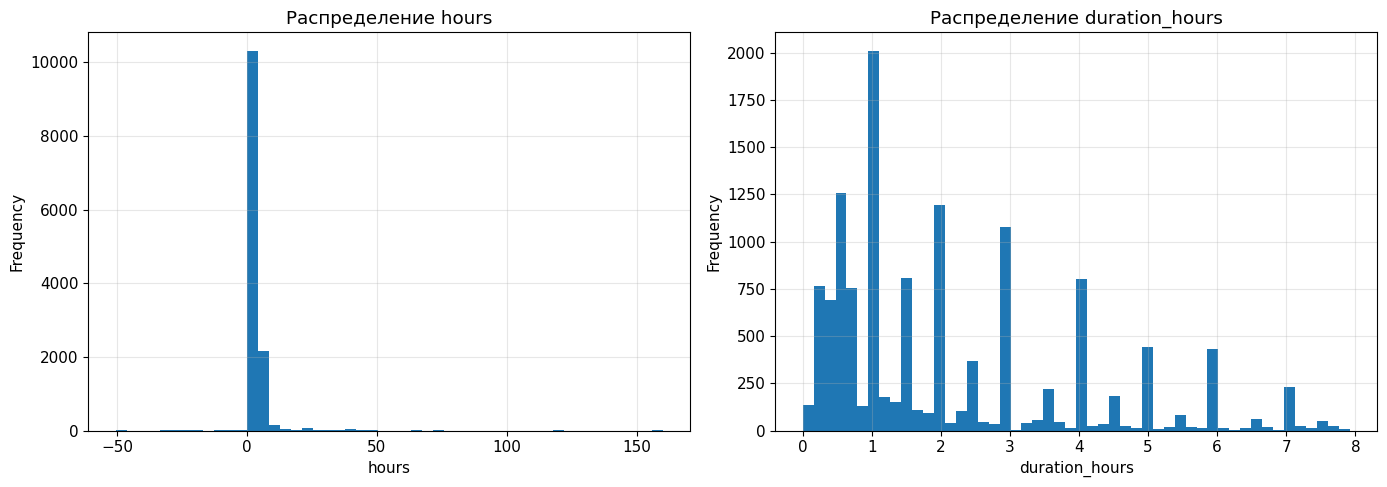

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df["hours"].plot(kind="hist", bins=50, ax=ax[0])
ax[0].set_title("Распределение hours")
ax[0].set_xlabel("hours")

if df["duration_hours"].notna().sum() > 0:
    df["duration_hours"].plot(kind="hist", bins=50, ax=ax[1])
    ax[1].set_title("Распределение duration_hours")
    ax[1].set_xlabel("duration_hours")
else:
    ax[1].text(0.5, 0.5, "duration_hours не удалось распарсить", ha="center", va="center")
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

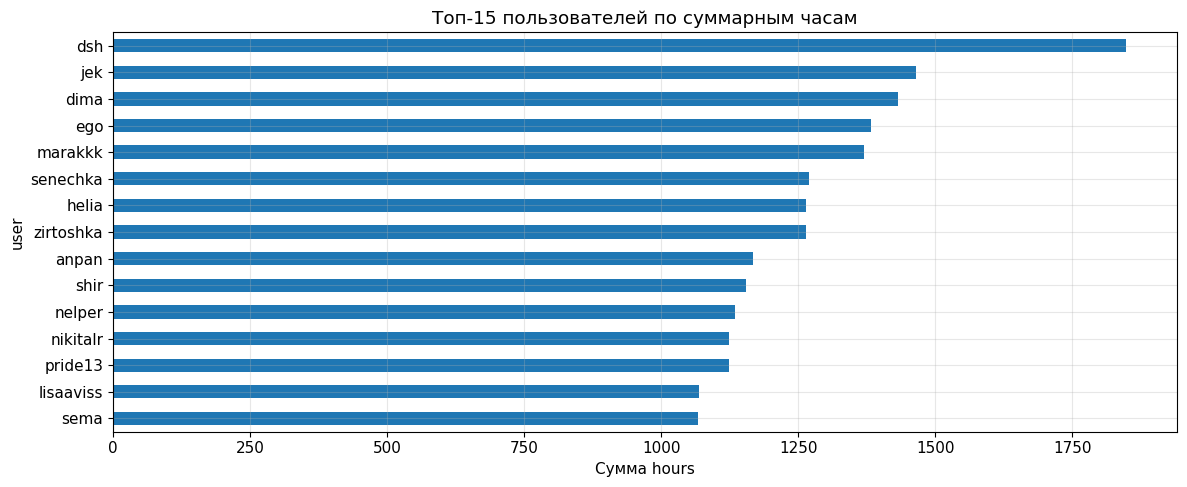

In [124]:
# Топ пользователей по суммарным часам
user_hours = (
    df.groupby("user", dropna=False)["hours"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

ax = user_hours.sort_values().plot(kind="barh")
ax.set_title("Топ-15 пользователей по суммарным часам")
ax.set_xlabel("Сумма hours")
ax.set_ylabel("user")
plt.tight_layout()
plt.show()

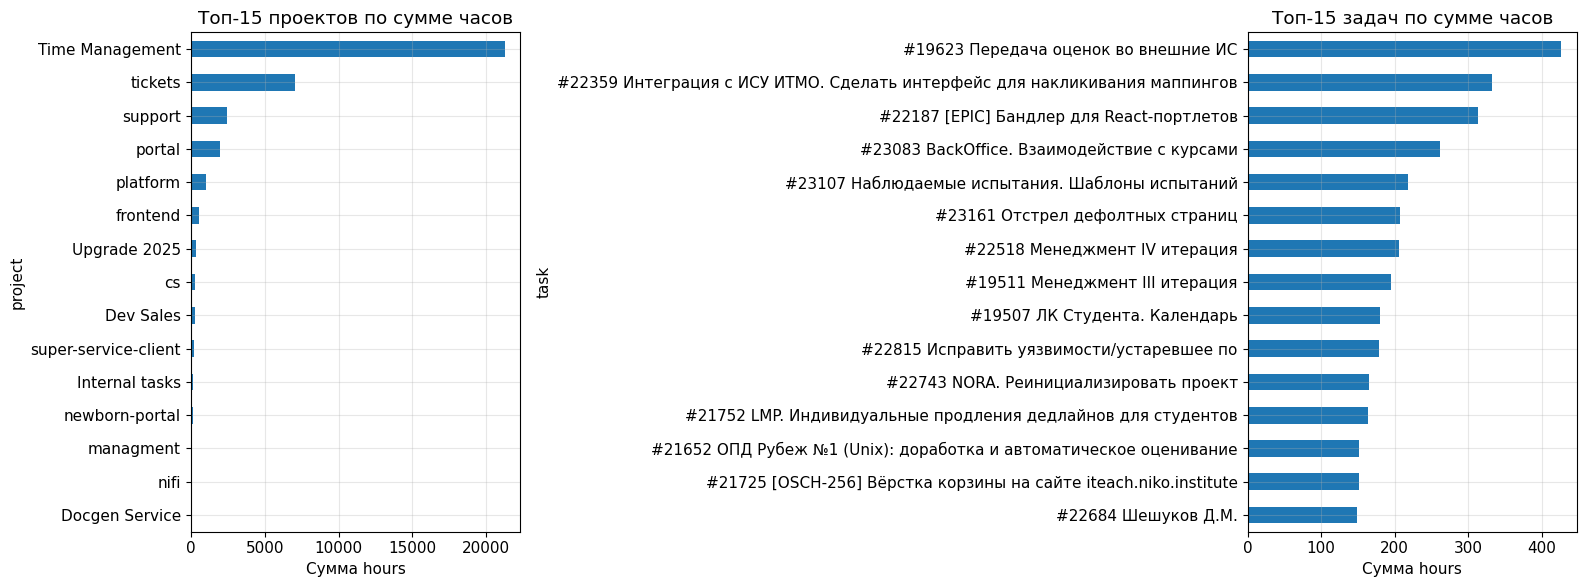

In [125]:
# Топ проектов и задач
project_hours = (
    df.groupby("project", dropna=False)["hours"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

task_hours = (
    df.groupby("task", dropna=False)["hours"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

project_hours.sort_values().plot(kind="barh", ax=ax[0])
ax[0].set_title("Топ-15 проектов по сумме часов")
ax[0].set_xlabel("Сумма hours")

task_hours.sort_values().plot(kind="barh", ax=ax[1])
ax[1].set_title("Топ-15 задач по сумме часов")
ax[1].set_xlabel("Сумма hours")

plt.tight_layout()
plt.show()

## 4. Анализ по дням недели

Здесь полезно смотреть не только сумму часов, но и среднее значение на день.  
Если у выходных среднее близко к будням, это не обязательно аномалия: данные могут отражать гибкий график или отложенное внесение времени.

,count,sum,mean,median
weekday,177,34721.52,196.16678,195.83
weekend,70,1727.24,24.674857,16.46


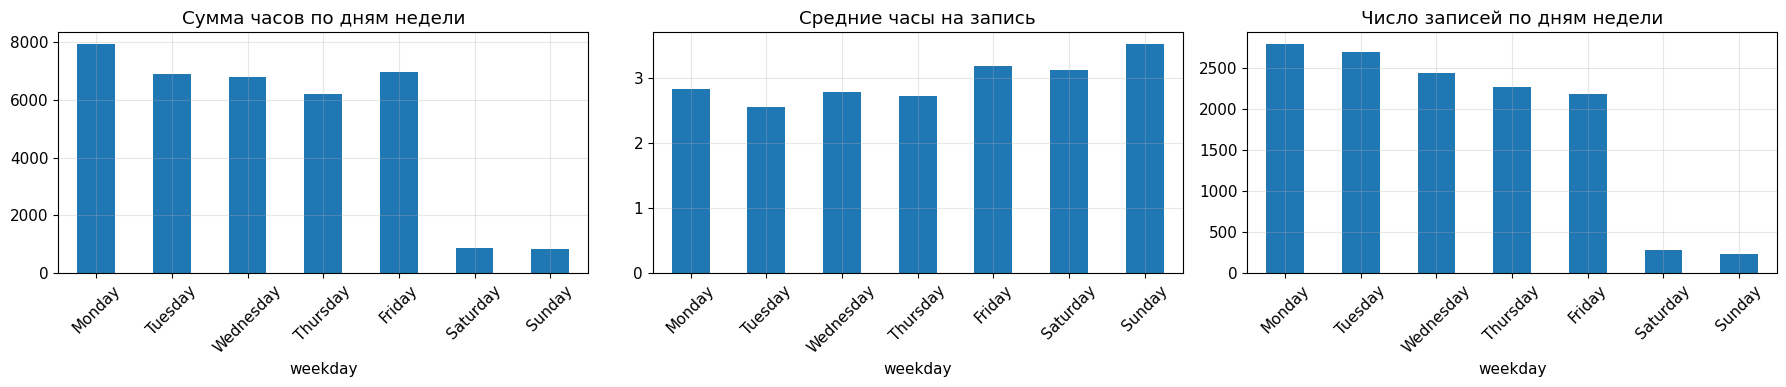

In [126]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_level = (
    df.groupby(["calendar_date", "is_weekend"], as_index=False)["hours"]
    .sum()
)

weekday_summary = day_level.groupby("is_weekend")["hours"].agg(["count", "sum", "mean", "median"])
weekday_summary.index = ["weekday", "weekend"]
display(weekday_summary)

weekday_stats = (
    df.groupby("weekday")
    .agg(
        total_hours=("hours", "sum"),
        mean_hours=("hours", "mean"),
        tracks=("hours", "size"),
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
weekday_stats["total_hours"].plot(kind="bar", ax=ax[0], title="Сумма часов по дням недели")
weekday_stats["mean_hours"].plot(kind="bar", ax=ax[1], title="Средние часы на запись")
weekday_stats["tracks"].plot(kind="bar", ax=ax[2], title="Число записей по дням недели")

for a in ax:
    a.set_xlabel("weekday")
    a.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Доля `mgmt/time`

Это один из самых полезных сигналов.  
Он показывает не “плохо/хорошо”, а насколько неделя заполнена общими, слабо привязанными к конкретной задаче записями.

Доля записей с mgmt/time: 49.48%
Доля часов, приходящаяся на mgmt/time: 58.23%


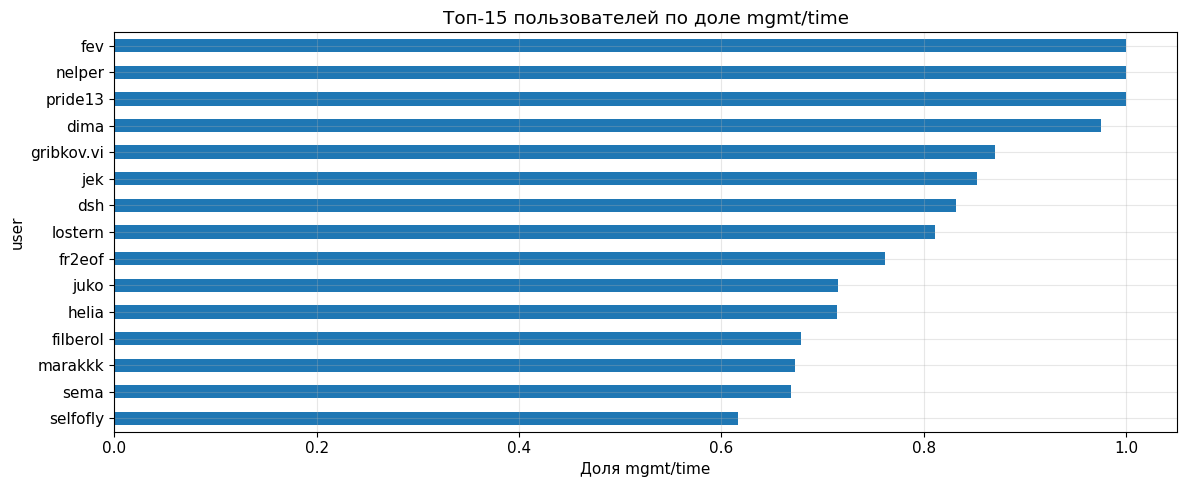

In [127]:
print(f"Доля записей с mgmt/time: {df['is_general_time'].mean():.2%}")
print(f"Доля часов, приходящаяся на mgmt/time: {df.loc[df['is_general_time'], 'hours'].sum() / df['hours'].sum():.2%}")

by_user_general = (
    df.groupby("user")
    .agg(
        total_hours=("hours", "sum"),
        general_hours=("hours", lambda s: s[df.loc[s.index, "is_general_time"]].sum()),
    )
)

by_user_general["general_share"] = by_user_general["general_hours"] / by_user_general["total_hours"]
by_user_general = by_user_general.sort_values("general_share", ascending=False).head(15)

ax = by_user_general["general_share"].sort_values().plot(kind="barh")
ax.set_title("Топ-15 пользователей по доле mgmt/time")
ax.set_xlabel("Доля mgmt/time")
ax.set_ylabel("user")
plt.tight_layout()
plt.show()

## 6. Сборка датасета на уровне пользователь-неделя

In [128]:
weekly = (
    df.groupby(["user", "name", "week_start"], as_index=False)
    .agg(
        total_hours=("hours", "sum"),
        avg_hours_per_track=("hours", "mean"),
        median_hours_per_track=("hours", "median"),
        max_hours_per_track=("hours", "max"),
        tracks=("hours", "size"),
        unique_projects=("project", "nunique"),
        unique_tasks=("task", "nunique"),
        weekend_tracks=("is_weekend", "sum"),
        weekend_hours=("hours", lambda s: s[df.loc[s.index, "is_weekend"]].sum()),
        empty_comment_share=("comment_is_empty", "mean"),
        avg_comment_len=("comment_len", "mean"),
        general_tracks=("is_general_time", "sum"),
        general_hours=("hours", lambda s: s[df.loc[s.index, "is_general_time"]].sum()),
    )
)

# Доли
weekly["general_share"] = weekly["general_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["weekend_share"] = weekly["weekend_hours"] / weekly["total_hours"].replace(0, np.nan)

# Бинарный признак: неделя с очень малым числом записей
weekly["is_small_week"] = (weekly["tracks"] <= 2).astype(int)

# Признак длинных записей
df["long_track"] = (df["hours"] >= 3).astype(int)
long_share = (
    df.groupby(["user", "week_start"], as_index=False)["long_track"]
    .mean()
    .rename(columns={"long_track": "long_track_share"})
)
weekly = weekly.merge(long_share, on=["user", "week_start"], how="left")

weekly.head()

,user,name,week_start,total_hours,avg_hours_per_track,median_hours_per_track,max_hours_per_track,tracks,unique_projects,unique_tasks,weekend_tracks,weekend_hours,empty_comment_share,avg_comment_len,general_tracks,general_hours,general_share,weekend_share,is_small_week,long_track_share
0,alexaks,Alexander Aksyonov,2025-08-26,40.0,40.0,40.0,40.0,1,1,1,0,0.0,0.0,12.000000,1,40.0,1.0,0.0,1,1.000000
1,alexaks,Alexander Aksyonov,2025-09-09,6.0,2.0,2.0,3.0,3,1,3,0,0.0,0.0,123.666667,0,0.0,0.0,0.0,0,0.333333
2,alexaks,Alexander Aksyonov,2025-09-16,1.0,1.0,1.0,1.0,1,1,1,0,0.0,0.0,13.000000,0,0.0,0.0,0.0,1,0.000000
3,alexaks,Alexander Aksyonov,2025-09-23,5.0,2.5,2.5,3.0,2,2,2,0,0.0,0.0,34.500000,0,0.0,0.0,0.0,1,0.500000
4,alexaks,Alexander Aksyonov,2025-09-30,19.17,2.13,2.0,4.0,9,3,6,0,0.0,0.0,101.222222,2,6.0,0.312989,0.0,0,0.333333


## 7. Proxy-target для бинарной классификации

Истинной метки “отлынивает / не отлынивает” здесь нет.  
Поэтому positive class строится как неделя повышенного риска для ручной проверки.

Используем признаки, которые действительно отражают качество трекинга:

- высокая доля `mgmt/time`;
- высокая доля пустых комментариев;
- высокая доля длинных записей;
- высокая концентрация времени в одной задаче;
- высокая доля выходных — только как вспомогательный сигнал;
- низкое разнообразие задач.

In [129]:
# Концентрация на одной задаче
task_hours = (
    df.groupby(["user", "week_start", "task"], as_index=False)["hours"]
    .sum()
)
top_task = (
    task_hours.sort_values(["user", "week_start", "hours"], ascending=[True, True, False])
    .groupby(["user", "week_start"], as_index=False)
    .head(1)[["user", "week_start", "hours"]]
    .rename(columns={"hours": "top_task_hours"})
)

# Концентрация на одном проекте
project_hours = (
    df.groupby(["user", "week_start", "project"], as_index=False)["hours"]
    .sum()
)
top_project = (
    project_hours.sort_values(["user", "week_start", "hours"], ascending=[True, True, False])
    .groupby(["user", "week_start"], as_index=False)
    .head(1)[["user", "week_start", "hours"]]
    .rename(columns={"hours": "top_project_hours"})
)

weekly = weekly.merge(top_task, on=["user", "week_start"], how="left")
weekly = weekly.merge(top_project, on=["user", "week_start"], how="left")

weekly["general_share"] = weekly["general_share"].fillna(0)
weekly["weekend_share"] = weekly["weekend_share"].fillna(0)
weekly["long_track_share"] = weekly["long_track_share"].fillna(0)
weekly["top_task_hours"] = weekly["top_task_hours"].fillna(0)
weekly["top_project_hours"] = weekly["top_project_hours"].fillna(0)

weekly["top_task_share"] = weekly["top_task_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["top_project_share"] = weekly["top_project_hours"] / weekly["total_hours"].replace(0, np.nan)

# Доли не должны быть больше 1
weekly["top_task_share"] = weekly["top_task_share"].fillna(0).clip(0, 1)
weekly["top_project_share"] = weekly["top_project_share"].fillna(0).clip(0, 1)

# Полезно убрать пустые недели
weekly = weekly[(weekly["tracks"] > 0) & (weekly["total_hours"] > 0)].copy()

def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    std = s.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

# Итоговый риск-скор
weekly["risk_score"] = (
        0.20 * zscore(weekly["long_track_share"]) +
        0.20 * zscore(weekly["top_task_share"]) +
        0.15 * zscore(weekly["top_project_share"]) +
        0.15 * zscore(weekly["empty_comment_share"]) +
        0.10 * zscore(weekly["general_share"]) +
        0.10 * zscore(weekly["weekend_share"]) +
        0.20 * zscore(weekly["is_small_week"])
)

# Proxy-label: верхние 15% по score
threshold = weekly["risk_score"].quantile(0.85)
weekly["risk_week"] = (weekly["risk_score"] >= threshold).astype(int)

print("Порог risk_score:", round(float(threshold), 3))
print("max top_task_share:", weekly["top_task_share"].max())
print("max top_project_share:", weekly["top_project_share"].max())


Порог risk_score: 0.521
max top_task_share: 1.0
max top_project_share: 1.0


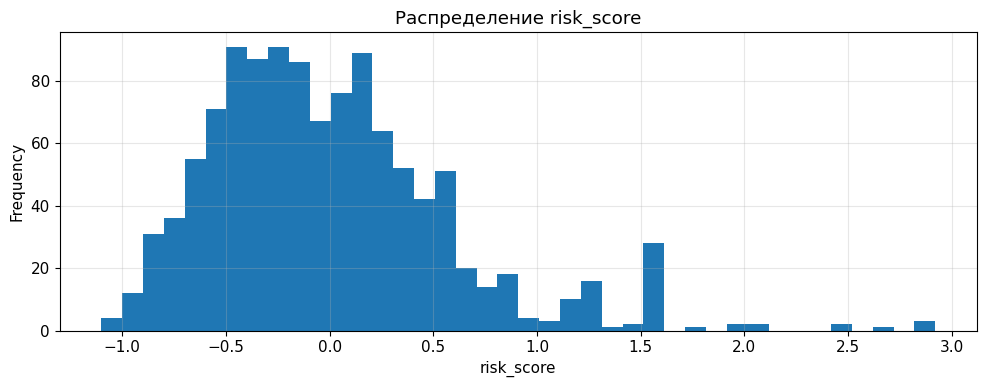

,user,name,week_start,risk_score,risk_week,general_share,empty_comment_share,top_task_share,top_project_share,long_track_share,weekend_share,is_small_week,tracks,unique_projects,unique_tasks,total_hours
87,batiskav03,Maxim Kalabukhov,2025-12-30,2.920253,1,1.0,1.0,1.0,1.0,1.000000,0.0,1,1,1,1,24.0
57,anpan,Aleksei Kondratev,2026-02-17,2.920253,1,1.0,1.0,1.0,1.0,1.000000,0.0,1,1,1,1,40.0
851,sema,Semyon Parshukov,2026-01-06,2.920253,1,1.0,1.0,1.0,1.0,1.000000,0.0,1,1,1,1,8.0
985,stoorx,Svyatoslav Osipov,2025-10-14,2.645766,1,0.0,1.0,1.0,1.0,1.000000,0.0,1,1,1,1,8.0
78,batiskav03,Maxim Kalabukhov,2025-10-28,2.431768,1,1.0,0.0,1.0,1.0,1.000000,1.0,1,1,1,1,48.0
885,senechka,Arseny Konovalov,2025-12-16,2.431768,1,1.0,0.0,1.0,1.0,1.000000,1.0,1,1,1,1,40.0
404,juko,Ivan Zhuk,2025-10-21,2.063750,1,1.0,0.5,0.827586,1.0,1.000000,0.0,1,2,1,2,29.0
796,salix,Alexander Verbovoy,2026-03-10,2.038598,1,1.0,0.5,0.8,1.0,1.000000,0.0,1,2,1,2,40.0
1061,victor,Victor Scherbackov,2026-04-07,1.969277,1,0.0,1.0,1.0,1.0,0.000000,0.0,1,1,1,1,2.0
620,osmi,Olga Smirnova,2026-01-13,1.969277,1,0.0,1.0,1.0,1.0,0.000000,0.0,1,1,1,1,0.17


In [130]:
plt.figure(figsize=(10, 4))
weekly["risk_score"].plot(kind="hist", bins=40)
plt.title("Распределение risk_score")
plt.xlabel("risk_score")
plt.tight_layout()
plt.show()

display(
    weekly.sort_values("risk_score", ascending=False)
    .head(15)[
        [
            "user", "name", "week_start", "risk_score", "risk_week",
            "general_share", "empty_comment_share", "top_task_share",
            "top_project_share", "long_track_share", "weekend_share",
            "is_small_week", "tracks", "unique_projects", "unique_tasks", "total_hours"
        ]
    ]
)

## 8. Какие признаки считаются правильными для этой задачи

### Основные признаки
- `general_share` — доля `mgmt/time`;
- `unique_tasks` и `unique_projects` — разнообразие работы;
- `empty_comment_share` и `avg_comment_len` — качество заполнения;
- `top_task_share` / `top_project_share` — концентрация на одной сущности;
- `long_track_share` — доля длинных записей.

### Вспомогательные признаки
- `weekend_share` — использовать аккуратно, как вспомогательный сигнал;
- `tracks` — число записей за неделю;
- `avg_hours_per_track`, `median_hours_per_track`, `max_hours_per_track`.

### Что не стоит делать
- не строить label только на основе выходных;
- не считать наличие `mgmt/time` само по себе “плохим”;
- не интерпретировать `date` как фактическое время работы в течение дня.

## 9. Выбор метрики качества

Основная метрика — **F2-score**.

Почему:
- положительный класс редкий;
- пропуск подозрительной недели дороже, чем лишняя ручная проверка;
- F2 сильнее штрафует false negative, чем F1.

Если потом задача будет решаться как ranking на ручную проверку, можно дополнительно смотреть Precision.

## 10. Вывод

1. Данные не являются “чистым графиком работы”; это журнал внесения времени.
2. Календарные признаки вроде выходных сами по себе малоинформативны.
3. Наиболее полезные сигналы — это структура трекинга: доля `mgmt/time`, разнообразие задач, качество комментариев, концентрация на одной задаче и доля длинных записей.
4. В качестве целевой переменной разумно использовать proxy-target “неделя повышенного риска для ручной проверки”.
5. Основная метрика — `F2-score`.